<a href="https://colab.research.google.com/github/wesleykieu/detecting-active-faults/blob/main/train_colab(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fault Detection — Fine-tuning Prithvi-EO 2.0 (600M)

**Objective 1A**: Fine-tune Prithvi-EO 2.0 to identify active faults from Sentinel-2 imagery.

Pipeline:
- Backbone: `prithvi_eo_v2_600m` (pretrained on 4.2M HLS samples)
- Decoder: `UperNetDecoder` with multi-scale features from layers [7, 15, 23, 31]
- Loss: Focal (handles ~1-5% fault pixel imbalance)
- Input: `[B, T=1, C=6, H=128, W=128]` patches
- Metrics: mIoU, F1, pixel accuracy

**Before running**: Upload `patches.zip` to `Google Drive/fault_detection_data/patches.zip`

In [8]:
# Fix widget metadata issue
import json, os

notebook_path = '/content/drive/MyDrive/Data Science/train_colab.ipynb'  # adjust path to your actual notebook

with open(notebook_path, 'r') as f:
    nb = json.load(f)

# Remove the broken widgets metadata
if 'widgets' in nb.get('metadata', {}):
    del nb['metadata']['widgets']

with open(notebook_path, 'w') as f:
    json.dump(nb, f, indent=1)

print('Fixed — widgets metadata removed')

Fixed — widgets metadata removed


In [ ]:
# ── 1. INSTALL DEPENDENCIES ──────────────────────────────────────────────────
# terratorch: official TerraTorch framework for Prithvi fine-tuning
# albumentations: data augmentation (used by TerraTorch transforms)
# einops: tensor rearranging (used internally by Prithvi)
# Pinning numpy<2 to avoid ImportError with PyTorch Lightning and SciPy

!pip install "numpy<2" terratorch albumentations einops timm -q

# Verify GPU
import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


PyTorch: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB
VRAM: 42.4 GB


In [7]:
# ── 2. MOUNT GOOGLE DRIVE ────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ── 3. COPY DATA FROM DRIVE → /content/ ──────────────────────────────────────
# /content/ is local SSD — much faster I/O than Drive during training

import os

DRIVE_ZIP = '/content/drive/MyDrive/Data Science/patches.zip'
LOCAL_ZIP = '/content/patches.zip'
LOCAL_DIR = '/content/data'

if not os.path.exists(f'{LOCAL_DIR}/patches/splits/train.txt'):
    print('Copying from Drive...')
    !cp "{DRIVE_ZIP}" "{LOCAL_ZIP}"
    print('Extracting...')
    !unzip -q "{LOCAL_ZIP}" -d "{LOCAL_DIR}"
    print('Done.')
else:
    print('Data already extracted.')

# Verify
with open(f'{LOCAL_DIR}/patches/splits/train.txt') as f:
    train_names = [l.strip() for l in f if l.strip()]
with open(f'{LOCAL_DIR}/patches/splits/val.txt') as f:
    val_names = [l.strip() for l in f if l.strip()]
with open(f'{LOCAL_DIR}/patches/splits/test.txt') as f:
    test_names = [l.strip() for l in f if l.strip()]

print(f'Train: {len(train_names):,}  Val: {len(val_names):,}  Test: {len(test_names):,}')

# Region breakdown
for region in ['carrizo', 'mojave', 'bay_area']:
    n = sum(1 for n in train_names if n.startswith(region))
    print(f'  {region}: {n} train patches')

Data already extracted.
Train: 2,943  Val: 630  Test: 634
  carrizo: 371 train patches
  mojave: 1498 train patches
  bay_area: 1074 train patches


In [ ]:
# ── 4. CONFIG ────────────────────────────────────────────────────────────────

# Paths
PATCHES_DIR    = f'{LOCAL_DIR}/patches'
IMAGES_DIR     = f'{PATCHES_DIR}/images'
LABELS_DIR     = f'{PATCHES_DIR}/labels'
SPLITS_DIR     = f'{PATCHES_DIR}/splits'
CHECKPOINT_DIR = '/content/checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# Model
BACKBONE    = 'prithvi_eo_v2_600_tl'  # 600M param base model
NUM_CLASSES = 2                      # 0=no fault, 1=fault
NUM_FRAMES  = 1                      # single Sentinel-2 composite (no time series)
IMG_SIZE    = 224

# Training — matches landslide4sense config from Prithvi-EO-2.0 repo
BATCH_SIZE   = 16    # A100 40GB handles this easily at 128x128
LR           = 5e-5  # AdamW lr from landslide config
WEIGHT_DECAY = 0.1
EPOCHS       = 80
PATIENCE     = 10    # early stopping patience (checks every 2 epochs)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Device: cuda


In [ ]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--force-reinstall", "numpy==1.26.4"], check=True)

CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', '-q', '--force-reinstall', 'numpy==1.26.4'], returncode=0)

In [ ]:
# ── 5. DATASET + DATA MODULE ─────────────────────────────────────────────────
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import lightning as L


# Computed from actual training data, not Prithvi defaults
HLS_MEANS = np.array([0.2450, 0.2683, 0.2772, 0.5264, 0.5096, 0.3233], dtype=np.float32)
HLS_STDS  = np.array([0.1367, 0.1292, 0.1273, 0.1571, 0.1231, 0.1201], dtype=np.float32)


class FaultPatchDataset(Dataset):
    """
    Loads 128x128 .npy patch pairs.
    Returns a dict matching TerraTorch's expected batch format:
      image : [C=6, T=1, H=128, W=128]  float32  — Prithvi expects [C, T, H, W]
      mask  : [H=128, W=128]             int64

    Normalization:
      GEE exports Sentinel-2 as integer reflectance scaled by 10000.
      We divide by 10000 to get [0, 1] reflectance, then apply Prithvi
      HLS per-band mean/std normalization to match the pretraining stats.
    """
    def __init__(self, split_file, images_dir, labels_dir, augment=False):
        with open(split_file) as f:
            self.names = [l.strip() for l in f if l.strip()]
        self.images_dir = Path(images_dir)
        self.labels_dir = Path(labels_dir)
        self.augment    = augment

    def __len__(self):
        return len(self.names)

    def __getitem__(self, idx):
        name = self.names[idx]
        img = np.load(self.images_dir / f'{name}.npy').astype(np.float32)  # [6, 128, 128]
        lbl = np.load(self.labels_dir / f'{name}.npy').astype(np.int64)    # [128, 128]

        # Replace NaN/Inf with 0 — some patches have NoData pixels from satellite orbit gaps
        np.nan_to_num(img, copy=False, nan=0.0, posinf=0.0, neginf=0.0)

        # --- normalize ---
        img = np.clip(img, 0.0, 1.0)
        img = (img - HLS_MEANS[:, None, None]) / HLS_STDS[:, None, None]

        # --- upscale 128 -> 224 to match Prithvi's native resolution ---
        img_t = torch.from_numpy(img).float().unsqueeze(0)
        img_t = torch.nn.functional.interpolate(
            img_t, size=(224, 224), mode='bilinear', align_corners=False
        ).squeeze(0)

        lbl_t = torch.from_numpy(lbl).float().unsqueeze(0).unsqueeze(0)
        lbl_t = torch.nn.functional.interpolate(
            lbl_t, size=(224, 224), mode='nearest'
        ).squeeze(0).squeeze(0).long()

        img = img_t.numpy()
        lbl = lbl_t.numpy()

        if self.augment:
          if np.random.random() > 0.5:
              img = img[:, :, ::-1].copy()
              lbl = lbl[:, ::-1].copy()
          if np.random.random() > 0.5:
              img = img[:, ::-1, :].copy()
              lbl = lbl[::-1, :].copy()
          # ADD: random 90/180/270 rotations — faults run at all angles
          k = np.random.randint(0, 4)
          if k:
              img = np.rot90(img, k, axes=(1, 2)).copy()
              lbl = np.rot90(lbl, k, axes=(0, 1)).copy()

        # [6, 224, 224] -> [6, 1, 224, 224]  (C, T, H, W) — required by Prithvi
        img = img[:, np.newaxis, :, :]

        return {
            "image": torch.from_numpy(img),
            "mask":  torch.from_numpy(lbl),
        }

    def plot(self, sample):
        return None


class FaultDataModule(L.LightningDataModule):
    def __init__(self, patches_dir, batch_size, num_workers=4):
        super().__init__()
        self.patches_dir = patches_dir
        self.batch_size  = batch_size
        self.num_workers = num_workers

    def setup(self, stage=None):
        # Named train_dataset / val_dataset / test_dataset — required by TerraTorch
        self.train_dataset = FaultPatchDataset(
            f'{self.patches_dir}/splits/train.txt',
            f'{self.patches_dir}/images',
            f'{self.patches_dir}/labels',
            augment=True,
        )
        self.val_dataset = FaultPatchDataset(
            f'{self.patches_dir}/splits/val.txt',
            f'{self.patches_dir}/images',
            f'{self.patches_dir}/labels',
        )
        self.test_dataset = FaultPatchDataset(
            f'{self.patches_dir}/splits/test.txt',
            f'{self.patches_dir}/images',
            f'{self.patches_dir}/labels',
        )

    def train_dataloader(self):
        return DataLoader(self.train_dataset, batch_size=self.batch_size,
                          shuffle=True, num_workers=self.num_workers, pin_memory=True)

    def val_dataloader(self):
        return DataLoader(self.val_dataset, batch_size=self.batch_size,
                          shuffle=False, num_workers=self.num_workers, pin_memory=True)

    def test_dataloader(self):
        return DataLoader(self.test_dataset, batch_size=self.batch_size,
                          shuffle=False, num_workers=self.num_workers, pin_memory=True)


datamodule = FaultDataModule(PATCHES_DIR, batch_size=BATCH_SIZE)
datamodule.setup()
print(f'Train: {len(datamodule.train_dataset):,}  Val: {len(datamodule.val_dataset):,}  Test: {len(datamodule.test_dataset):,}')

# Sanity-check normalization — post-normalization values should be roughly N(0, 1)
sample = datamodule.train_dataset[0]
img, lbl = sample["image"], sample["mask"]
print(f'\nImage shape: {tuple(img.shape)}  →  expect (6, 1, 128, 128)')
print(f'Label shape: {tuple(lbl.shape)}  →  expect (128, 128)')
print(f'Image stats after normalization:')
print(f'  min:   {img.min().item():+.3f}')
print(f'  max:   {img.max().item():+.3f}')
print(f'  mean:  {img.mean().item():+.3f}  (should be near 0)')
print(f'  std:   {img.std().item():+.3f}  (should be near 1)')
print(f'Fault pixels: {lbl.float().mean()*100:.2f}%')


Train: 2,943  Val: 630  Test: 634

Image shape: (6, 1, 224, 224)  →  expect (6, 1, 128, 128)
Label shape: (224, 224)  →  expect (128, 128)
Image stats after normalization:
  min:   -4.140
  max:   +4.899
  mean:  +0.000  (should be near 0)
  std:   +0.962  (should be near 1)
Fault pixels: 15.43%


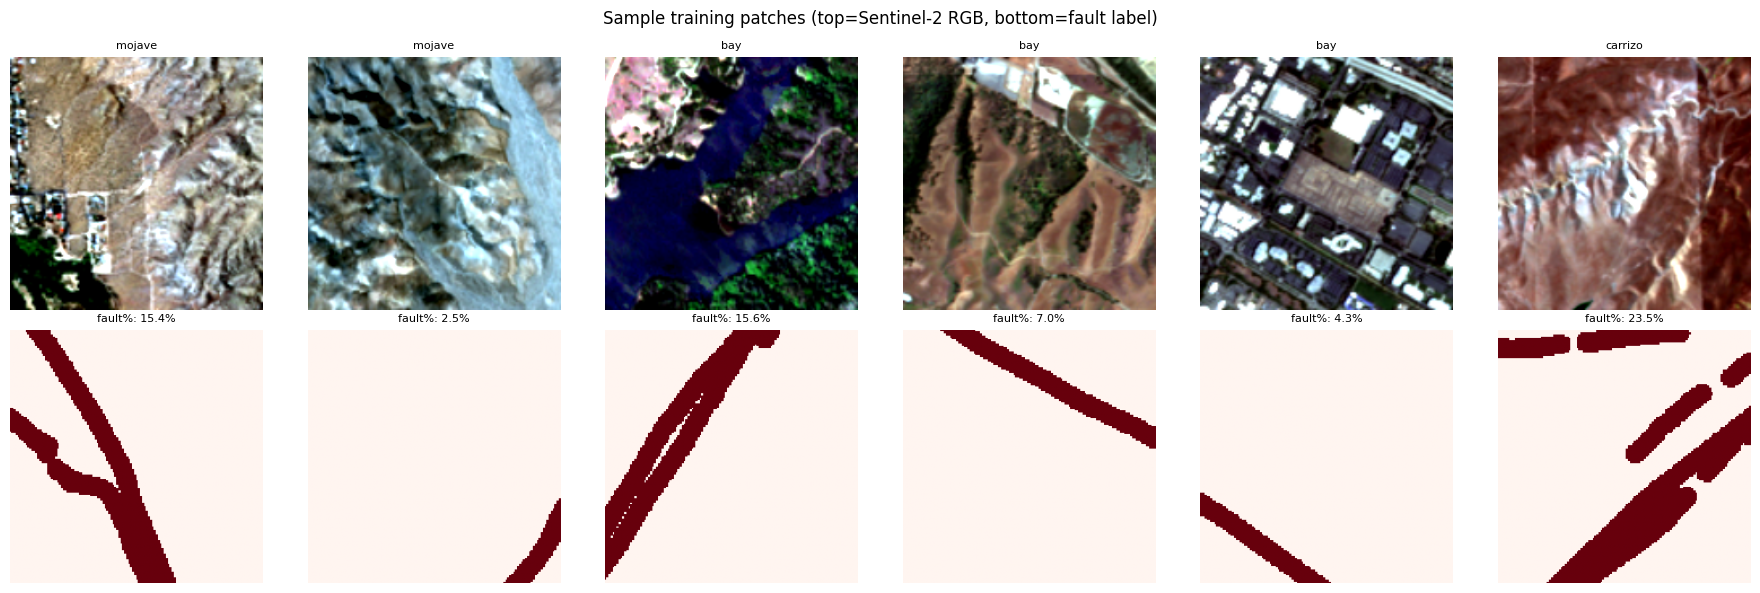

In [ ]:
# ── 6. VISUALIZE SAMPLE PATCHES ──────────────────────────────────────────────
import matplotlib.pyplot as plt

def denormalize_rgb(img_chw, channels=(2, 1, 0)):
    """Given a normalized [C, T, H, W] or [C, H, W] tensor, return an RGB HxWx3
       array scaled into a visible range. Uses the R, G, B channel indices."""
    if img_chw.dim() == 4:
        img_chw = img_chw[:, 0]   # drop T dim -> [C, H, W]
    means = torch.tensor(HLS_MEANS, dtype=img_chw.dtype).view(-1, 1, 1)
    stds  = torch.tensor(HLS_STDS,  dtype=img_chw.dtype).view(-1, 1, 1)
    img_reflectance = img_chw * stds + means      # back to [0, 1] reflectance
    rgb = img_reflectance[list(channels)].permute(1, 2, 0).numpy()
    # percentile stretch for nicer display
    lo, hi = np.percentile(rgb, (2, 98))
    rgb = np.clip((rgb - lo) / (hi - lo + 1e-8), 0, 1)
    return rgb

fig, axes = plt.subplots(2, 6, figsize=(18, 6))

for i in range(6):
    sample = datamodule.train_dataset[i * 20]
    img, lbl = sample["image"], sample["mask"]
    rgb = denormalize_rgb(img)

    axes[0, i].imshow(rgb)
    axes[0, i].set_title(datamodule.train_dataset.names[i * 20].split('_')[0], fontsize=8)
    axes[0, i].axis('off')

    axes[1, i].imshow(lbl.numpy(), cmap='Reds', vmin=0, vmax=1)
    axes[1, i].set_title(f'fault%: {lbl.float().mean()*100:.1f}%', fontsize=8)
    axes[1, i].axis('off')

plt.suptitle('Sample training patches (top=Sentinel-2 RGB, bottom=fault label)', fontsize=12)
plt.tight_layout()
plt.show()


In [ ]:
# ── 7. BUILD MODEL ───────────────────────────────────────────────────────────
import terratorch
import terratorch.models
import terratorch.models.backbones
from terratorch.tasks import SemanticSegmentationTask

model_args = {
    'backbone'          : BACKBONE,
    'decoder'           : 'UperNetDecoder',
    'num_classes'       : NUM_CLASSES,
    'rescale'           : True,
    'head_dropout'      : 0.1,
    'decoder_channels'  : 256,
    'head_channel_list' : [128, 64],
    'necks': [
        {'name': 'SelectIndices', 'indices': [7, 15, 23, 31]},
        {'name': 'ReshapeTokensToImage'},
    ],
    'backbone_kwargs': {
        'num_frames' : NUM_FRAMES,
        'pretrained' : True,
        'bands'      : ['BLUE', 'GREEN', 'RED', 'NIR_BROAD', 'SWIR_1', 'SWIR_2'],
    },
}

task = SemanticSegmentationTask(
    model_args     = model_args,
    model_factory  = 'EncoderDecoderFactory',
    loss           = 'ce',
    class_weights  = [1.0, 8.0],
    ignore_index   = -1,
    freeze_backbone= False,
    freeze_decoder = False,
)

total_params     = sum(p.numel() for p in task.parameters())
trainable_params = sum(p.numel() for p in task.parameters() if p.requires_grad)
print(f'Total params:     {total_params:,}')
print(f'Trainable params: {trainable_params:,}')

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Prithvi_EO_V2_600M_TL.pt:   0%|          | 0.00/2.64G [00:00<?, ?B/s]

Total params:     643,294,532
Trainable params: 643,294,532


In [ ]:
# ── COMBINED LOSS: Cross-Entropy + Dice ──────────────────────────────────────
import torch.nn as nn
import torch.nn.functional as F

class CombinedCEDiceLoss(nn.Module):
    def __init__(self, ce_weight, dice_weight=0.5):
        super().__init__()
        self.ce = nn.CrossEntropyLoss(
            weight=torch.tensor(ce_weight).float().to(DEVICE),
            ignore_index=-1
        )
        self.dice_weight = dice_weight

    def forward(self, logits, targets):
        # Cross-entropy term
        ce_loss = self.ce(logits, targets)

        # Dice term — operates on fault class probabilities
        probs = torch.softmax(logits, dim=1)[:, 1]       # [B, H, W]
        valid = (targets != -1)
        p = probs[valid]
        t = targets[valid].float()
        intersection = (p * t).sum()
        dice_loss = 1 - (2 * intersection + 1) / \
                    (p.sum() + t.sum() + 1)

        return ce_loss + self.dice_weight * dice_loss

# Override task criterion
task.criterion = CombinedCEDiceLoss(
    ce_weight=[1.0, 8.0],   # back to original
    dice_weight=0.0          # effectively CE only
)
print(f'Loss: CE(weights=[1.0, 8.0]) + 0.5 × Dice')
print(f'Criterion: {task.criterion}')

Loss: CE(weights=[1.0, 8.0]) + 0.5 × Dice
Criterion: CombinedCEDiceLoss(
  (ce): CrossEntropyLoss()
)


In [ ]:
# ── 8. OPTIMIZER + SCHEDULER ─────────────────────────────────────────────────
#
# TerraTorch's SemanticSegmentationTask inherits configure_optimizers from
# its parent. We override it here to set AdamW + CosineAnnealingLR,
# matching the landslide4sense config exactly.
#
import torch.optim as optim

def configure_optimizers(self):
    # Split params: encoder = slow LR, decoder+head = fast LR
    encoder_params = [p for n, p in self.named_parameters() if 'encoder' in n]
    head_params    = [p for n, p in self.named_parameters() if 'encoder' not in n]
    print(f"encoder params: {sum(p.numel() for p in encoder_params):,}")
    print(f"head params:    {sum(p.numel() for p in head_params):,}")

    optimizer = optim.AdamW([
        {'params': encoder_params, 'lr': 5e-5},
        {'params': head_params,    'lr': 1e-4},   # 10x higher for fresh decoder
    ], weight_decay=WEIGHT_DECAY)

    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=EPOCHS,
        eta_min=1e-7,
    )
    return {
        'optimizer': optimizer,
        'lr_scheduler': {'scheduler': scheduler, 'interval': 'epoch'},
    }

# Bind to task instance
import types
task.configure_optimizers = types.MethodType(configure_optimizers, task)
print('Optimizer configured: AdamW lr=5e-5, CosineAnnealingLR')

Optimizer configured: AdamW lr=5e-5, CosineAnnealingLR


In [ ]:
print(task.criterion)
print(task.criterion.ce.weight)  # weight lives inside the .ce sub-module now

CombinedCEDiceLoss(
  (ce): CrossEntropyLoss()
)
tensor([1., 8.], device='cuda:0')


In [ ]:
task.train()
print(f'Model mode check: {next(task.parameters()).requires_grad}')  # should be True

Model mode check: True


In [ ]:
# ── 9. TRAIN ─────────────────────────────────────────────────────────────────
from lightning.pytorch.callbacks import (
    ModelCheckpoint,
    LearningRateMonitor,
    EarlyStopping,
    RichProgressBar,
)

checkpoint_cb = ModelCheckpoint(
    dirpath    = CHECKPOINT_DIR,
    filename   = 'prithvi600m-fault-exp2-{epoch:02d}-{val/mIoU:.4f}',
    monitor    = 'val/mIoU',
    mode       = 'max',
    save_top_k = 1,
    save_last  = True,
)

early_stop_cb = EarlyStopping(
    monitor       = 'val/mIoU',
    patience      = 15,
    mode          = 'max',
    check_finite  = False,
)

trainer = L.Trainer(
    max_epochs              = EPOCHS,
    accelerator             = 'gpu',
    devices                 = 1,
    precision               = '32-true',
    gradient_clip_val       = 1.0,
    check_val_every_n_epoch = 2,
    log_every_n_steps       = 10,
    enable_checkpointing    = True,
    default_root_dir        = CHECKPOINT_DIR,
    callbacks=[
        checkpoint_cb,
        early_stop_cb,
        LearningRateMonitor(logging_interval='epoch'),
        RichProgressBar(),
    ],
)

trainer.fit(task, datamodule=datamodule)
print(f'\nBest checkpoint: {checkpoint_cb.best_model_path}')
print(f'Best val/loss:   {checkpoint_cb.best_model_score:.4f}')

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/callbacks/model_checkpoint.py:654: Checkpoint directory /content/checkpoints exists and is not empty.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


encoder params: 631,188,482
head params:    12,106,050


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type               ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ model         │ PixelWiseModel     │  643 M │ train │
│ 1 │ criterion     │ CombinedCEDiceLoss │      0 │ train │
│ 2 │ train_metrics │ MetricCollection   │      0 │ train │
│ 3 │ val_metrics   │ MetricCollection   │      0 │ train │
│ 4 │ test_metrics  │ ModuleList         │      0 │ train │
└───┴───────────────┴────────────────────┴────────┴───────┘

Trainable params: 643 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 643 M                                                                                                
Total estimated model params size (MB): 2.6 K                                                                      
Modules in train mode: 824                                                                                         
Modules in eval mode: 0

Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: The ``compute`` method of
metric MulticlassAccuracy was called before the ``update`` method which may lead to errors, as metric states have 
not yet been updated.
  warnings.warn(*args, **kwargs)

INFO: `Trainer.fit` stopped: `max_epochs=80` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=80` reached.



Best checkpoint: /content/checkpoints/prithvi600m-fault-exp2-epoch=77-val/mIoU=0.7427.ckpt
Best val/loss:   0.7427


In [ ]:
# ── 10. EVALUATE ON TEST SET ─────────────────────────────────────────────────
# Load best checkpoint and run test split
# TerraTorch's SemanticSegmentationTask logs:
#   test/loss, test/Multiclass_Jaccard_Index (mIoU), test/Multiclass_F1Score

best_ckpt = checkpoint_cb.best_model_path
print(f'Loading checkpoint: {best_ckpt}')

test_results = trainer.test(task, datamodule=datamodule, ckpt_path=best_ckpt)
print('\n=== TEST RESULTS ===')
for k, v in test_results[0].items():
    print(f'  {k}: {v:.4f}')

INFO: Restoring states from the checkpoint path at /content/checkpoints/prithvi600m-fault-exp2-epoch=77-val/mIoU=0.7427.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /content/checkpoints/prithvi600m-fault-exp2-epoch=77-val/mIoU=0.7427.ckpt


Loading checkpoint: /content/checkpoints/prithvi600m-fault-exp2-epoch=77-val/mIoU=0.7427.ckpt


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loaded model weights from the checkpoint at /content/checkpoints/prithvi600m-fault-exp2-epoch=77-val/mIoU=0.7427.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Loaded model weights from the checkpoint at /content/checkpoints/prithvi600m-fault-exp2-epoch=77-val/mIoU=0.7427.ckpt


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test/Accuracy       │    0.8514427542686462     │
│    test/Boundary_mIoU     │    0.22744180262088776    │
│   test/Class_Accuracy_0   │    0.9651707410812378     │
│   test/Class_Accuracy_1   │    0.7377147674560547     │
│       test/F1_Score       │    0.8400252461433411     │
│        test/IoU_0         │    0.9397001266479492     │
│        test/IoU_1         │    0.5517561435699463     │
│    test/Pixel_Accuracy    │    0.9438666105270386     │
│         test/loss         │     0.977535605430603     │
│         test/mIoU         │    0.7457281351089478     │
│      test/mIoU_Micro      │    0.8937002420425415     │
└───────────────────────────┴───────────────────────────┘


=== TEST RESULTS ===
  test/loss: 0.9775
  test/Accuracy: 0.8514
  test/Boundary_mIoU: 0.2274
  test/Class_Accuracy_0: 0.9652
  test/Class_Accuracy_1: 0.7377
  test/F1_Score: 0.8400
  test/IoU_0: 0.9397
  test/IoU_1: 0.5518
  test/Pixel_Accuracy: 0.9439
  test/mIoU: 0.7457
  test/mIoU_Micro: 0.8937


In [ ]:
# ── 11. MANUAL METRICS (mIoU, F1, pixel accuracy) ────────────────────────────
# Compute per-patch metrics manually to report exactly what the proposal requires:
# mIoU, F1, pixel accuracy  (Objective 1A evaluation)
#
# NOTE: dataloader yields dicts {"image": ..., "mask": ...}, NOT tuples.

task.eval().to(DEVICE)

tp_total = fp_total = fn_total = tn_total = 0

with torch.no_grad():
    for batch in datamodule.test_dataloader():
        imgs = batch["image"].to(DEVICE)   # [B, 6, 1, 128, 128]
        lbls = batch["mask"].to(DEVICE)    # [B, 128, 128]

        out    = task(imgs)                # ModelOutput or tensor
        logits = out.output if hasattr(out, 'output') else out
        probs = torch.softmax(logits, dim=1)[:, 1]
        preds = (probs > 0.70).long()

        tp_total += ((preds == 1) & (lbls == 1)).sum().item()
        fp_total += ((preds == 1) & (lbls == 0)).sum().item()
        fn_total += ((preds == 0) & (lbls == 1)).sum().item()
        tn_total += ((preds == 0) & (lbls == 0)).sum().item()

iou       = tp_total / (tp_total + fp_total + fn_total + 1e-8)
f1        = 2 * tp_total / (2 * tp_total + fp_total + fn_total + 1e-8)
pix_acc   = (tp_total + tn_total) / (tp_total + fp_total + fn_total + tn_total + 1e-8)
precision = tp_total / (tp_total + fp_total + 1e-8)
recall    = tp_total / (tp_total + fn_total + 1e-8)

# mIoU = mean of per-class IoU (background + fault)
iou_bg    = tn_total / (tn_total + fp_total + fn_total + 1e-8)
mean_iou  = (iou_bg + iou) / 2

print('=== OBJECTIVE 1A — TEST SET METRICS ===')
print(f'  mIoU (mean of classes): {mean_iou:.4f}')
print(f'  IoU (fault class):      {iou:.4f}')
print(f'  IoU (background):       {iou_bg:.4f}')
print(f'  F1 score (fault):       {f1:.4f}')
print(f'  Pixel accuracy:         {pix_acc:.4f}')
print(f'  Precision (fault):      {precision:.4f}')
print(f'  Recall (fault):         {recall:.4f}')


=== OBJECTIVE 1A — TEST SET METRICS ===
  mIoU (mean of classes): 0.7472
  IoU (fault class):      0.5514
  IoU (background):       0.9430
  F1 score (fault):       0.7108
  Pixel accuracy:         0.9467
  Precision (fault):      0.7227
  Recall (fault):         0.6993


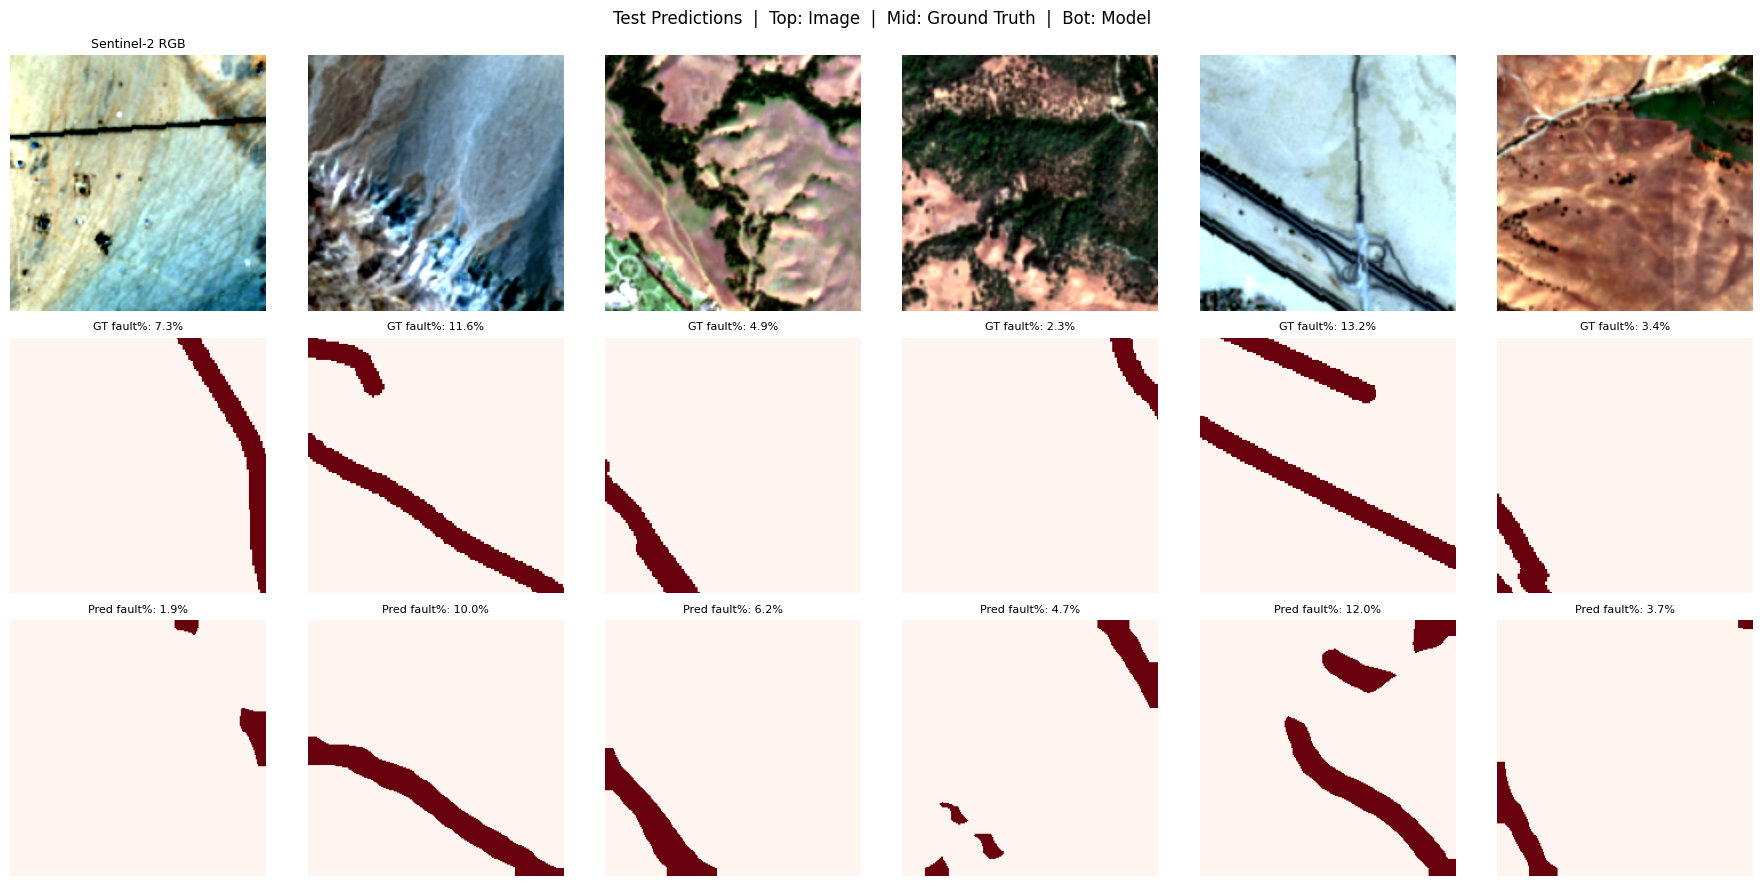

In [ ]:
# ── 12. VISUALIZE PREDICTIONS ────────────────────────────────────────────────
# Show image / ground truth / prediction for 6 test patches

import matplotlib.pyplot as plt
import torch
import numpy as np

def denormalize_rgb(img_chw, channels=(2, 1, 0)):
    """Given a normalized [C, T, H, W] or [C, H, W] tensor, return an RGB HxWx3
       array scaled into a visible range. Uses the R, G, B channel indices."""
    if img_chw.dim() == 4:
        img_chw = img_chw[:, 0]   # drop T dim -> [C, H, W]
    means = torch.tensor(HLS_MEANS, dtype=img_chw.dtype).view(-1, 1, 1)
    stds  = torch.tensor(HLS_STDS,  dtype=img_chw.dtype).view(-1, 1, 1)
    img_reflectance = img_chw * stds + means      # back to [0, 1] reflectance
    rgb = img_reflectance[list(channels)].permute(1, 2, 0).numpy()
    # percentile stretch for nicer display
    lo, hi = np.percentile(rgb, (2, 98))
    rgb = np.clip((rgb - lo) / (hi - lo + 1e-8), 0, 1)
    return rgb

task.eval().to(DEVICE)

# Grab one batch — dataloader yields a dict
batch = next(iter(datamodule.test_dataloader()))
imgs_batch, lbls_batch = batch["image"], batch["mask"]

with torch.no_grad():
    out    = task(imgs_batch.to(DEVICE))
    logits = out.output if hasattr(out, 'output') else out
    probs = torch.softmax(logits, dim=1)[:, 1].cpu()  # move to CPU here
    preds = (probs > 0.50).long()                      # now on CPU already

n_show = 6
fig, axes = plt.subplots(3, n_show, figsize=(18, 9))

for i in range(n_show):
    # imgs_batch[i] is [C=6, T=1, H, W]; use the helper from cell 6
    rgb = denormalize_rgb(imgs_batch[i])

    axes[0, i].imshow(rgb)
    axes[0, i].set_title('Sentinel-2 RGB' if i == 0 else '', fontsize=9)
    axes[0, i].axis('off')

    axes[1, i].imshow(lbls_batch[i].numpy(), cmap='Reds', vmin=0, vmax=1)
    axes[1, i].set_title(f'GT fault%: {lbls_batch[i].float().mean()*100:.1f}%', fontsize=8)
    axes[1, i].axis('off')

    axes[2, i].imshow(preds[i].numpy(), cmap='Reds', vmin=0, vmax=1)
    axes[2, i].set_title(f'Pred fault%: {preds[i].float().mean()*100:.1f}%', fontsize=8)
    axes[2, i].axis('off')

plt.suptitle('Test Predictions  |  Top: Image  |  Mid: Ground Truth  |  Bot: Model', fontsize=12)
plt.tight_layout()
plt.savefig(f'{CHECKPOINT_DIR}/predictions.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Check what the criterion actually looks like
print(task.criterion)
print(type(task.criterion))
if hasattr(task.criterion, 'weight'):
    print(f"weight: {task.criterion.weight}")
if hasattr(task.criterion, 'pos_weight'):
    print(f"pos_weight: {task.criterion.pos_weight}")

CombinedCEDiceLoss(
  (ce): CrossEntropyLoss()
)
<class '__main__.CombinedCEDiceLoss'>


In [ ]:
# DIAGNOSTIC — run after cell 5 (dataset setup)
import numpy as np
import torch

# 1. Check raw data statistics BEFORE my normalization
ds_raw = datamodule.train_dataset
name = ds_raw.names[0]
raw = np.load(f'{ds_raw.images_dir}/{name}.npy').astype(np.float32)
print(f"=== RAW .npy file stats ===")
print(f"shape: {raw.shape}, dtype: {raw.dtype}")
print(f"overall min/max/mean: {raw.min():.2f} / {raw.max():.2f} / {raw.mean():.2f}")
print(f"per-band means: {raw.mean(axis=(1,2))}")
print(f"per-band stds:  {raw.std(axis=(1,2))}")

# 2. Check after my normalization
sample = ds_raw[0]
img = sample["image"]
print(f"\n=== After normalization (what model sees) ===")
print(f"shape: {tuple(img.shape)}")
print(f"overall min/max/mean/std: {img.min():.3f} / {img.max():.3f} / {img.mean():.3f} / {img.std():.3f}")
print(f"per-band means: {img.mean(dim=(1,2,3)).tolist()}")
print(f"per-band stds:  {img.std(dim=(1,2,3)).tolist()}")

# 3. Check if the model produces NaN on a single forward pass (before training)
print(f"\n=== Single forward pass test ===")
task.eval().to(DEVICE)
with torch.no_grad():
    batch = next(iter(datamodule.train_dataloader()))
    imgs = batch["image"].to(DEVICE)
    out = task(imgs)
    logits = out.output if hasattr(out, 'output') else out
    print(f"logits shape: {logits.shape}")
    print(f"logits min/max/mean: {logits.min().item():.3f} / {logits.max().item():.3f} / {logits.mean().item():.3f}")
    print(f"any NaN in logits?  {torch.isnan(logits).any().item()}")
    print(f"any Inf in logits?  {torch.isinf(logits).any().item()}")

=== RAW .npy file stats ===
shape: (6, 128, 128), dtype: float32
overall min/max/mean: 0.00 / 1.00 / 0.36
per-band means: [0.24498425 0.26829022 0.27719557 0.52636415 0.50963235 0.32334846]
per-band stds:  [0.13673209 0.12920552 0.12734805 0.15714797 0.12311234 0.12009682]

=== After normalization (what model sees) ===
shape: (6, 1, 224, 224)
overall min/max/mean/std: -4.140 / 4.899 / 0.000 / 0.962
per-band means: [-0.00024244820815511048, -0.00011465531133580953, -3.8147278246469796e-05, -0.00017693349218461663, 0.00032482598908245564, 0.00046969743561930954]
per-band stds:  [0.9394804239273071, 0.9424974918365479, 0.9544801712036133, 0.9726648330688477, 0.9799948930740356, 0.9792461395263672]

=== Single forward pass test ===
logits shape: torch.Size([16, 2, 224, 224])
logits min/max/mean: -46.050 / 34.799 / -2.074
any NaN in logits?  False
any Inf in logits?  False


In [ ]:
# ── 13. SAVE CHECKPOINT + RESULTS TO DRIVE ───────────────────────────────────
import shutil

DRIVE_OUTPUT = '/content/drive/MyDrive/fault_detection_data/checkpoints'
os.makedirs(DRIVE_OUTPUT, exist_ok=True)

# Copy best checkpoint
shutil.copy(checkpoint_cb.best_model_path, DRIVE_OUTPUT)
shutil.copy(f'{CHECKPOINT_DIR}/predictions.png', DRIVE_OUTPUT)

# Save metrics
import json
metrics = {
    'mIoU'           : round(iou, 4),
    'F1'             : round(f1, 4),
    'pixel_accuracy' : round(pix_acc, 4),
    'precision'      : round(precision, 4),
    'recall'         : round(recall, 4),
    'best_val_loss'  : float(checkpoint_cb.best_model_score),
    'backbone'       : BACKBONE,
    'epochs_trained' : trainer.current_epoch,
}
with open(f'{DRIVE_OUTPUT}/metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print('Saved to Drive:')
for item in os.listdir(DRIVE_OUTPUT):
    print(f'  {DRIVE_OUTPUT}/{item}')